In [ ]:
import glob
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from pyproj import Proj
import xarray
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from datetime import timedelta, datetime

import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

jet = cm.get_cmap('jet', 256)
newcolors = jet(np.linspace(0.2, 1.0, 256))  # skip darkest 20%
lighter_jet = ListedColormap(newcolors)
# Constants
P0 = 101325 #101325  # sea-level pressure in Pa
T0 = 288.15  # standard temperature in K
g = 9.80665  # gravity in m/s^2
R = 287.05   # specific gas constant for dry air in J/(kg·K)

#MUSICAv0 in kg/kg
#to P3 ug/m3
# rho_air = 1.225 kg m-3 at STP
p3_ug_m3 = 1.225*1000*1E6

/tmp/ipykernel_113092/3271084443.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  jet = cm.get_cmap('jet', 256)


In [3]:
color_dict = {'lightblue': '#e9faff',
              'skyblue': '#8ce2ff',
              'ygreen': '#c3f448',
              'yellow': '#faff00',
              'yorange': '#ef0100',
              'maroon': '#690100'}

mycolorbar = LinearSegmentedColormap.from_list('mycolorbar', [
    color_dict['lightblue'],
    color_dict['skyblue'],
    color_dict['ygreen'],
    color_dict['yellow'],
    color_dict['yorange'],
])

In [4]:
dat = '20190915'
dat1 = '2019-09-15-03600'
dat2 = '2019-09-16-03600'
workdir = '/home/svisaga/MUSICA_ANALYSES/WWW-AIR_1726704979598/'
p3file = f'CAMP2Ex-mrg01-P3B-NC_merge_{dat}_R3.nc'
p3data_ds = xarray.open_dataset(workdir+p3file)
p3data_ds
variables = ['Org_Ave_IsoK_STP', 'mz42_Ave_IsoK_STP', 'mz43_Ave_IsoK_STP', 'mz44_Ave_IsoK_STP', 'mz60_Ave_IsoK_STP', 'U', 'V']
selected_data = p3data_ds[variables]
p3data = selected_data.to_dataframe().reset_index()

In [ ]:
df = p3data
df = df[df['Org_Ave_IsoK_STP']>=40]
# Southwesternmost point: minimum latitude + minimum longitude
sw_point = df.loc[df.assign(
    lat_rank=df['lat'].rank(method='min'),
    lon_rank=df['lon'].rank(method='min')
).eval('lat_rank + lon_rank').idxmin()]

# Southeasternmost point: minimum latitude + maximum longitude
se_point = df.loc[df.assign(
    lat_rank=df['lat'].rank(method='min'),
    lon_rank=-df['lon'].rank(method='min')  # negate to rank max lon
).eval('lat_rank + lon_rank').idxmin()]

print("Southwesternmost point:\n", sw_point)
print("\nSoutheasternmost point:\n", se_point)

Southwesternmost point:
 time                 2019-09-16 01:45:23.500000
Org_Ave_IsoK_STP                         40.209
mz42_Ave_IsoK_STP                         1.595
mz43_Ave_IsoK_STP                         3.286
mz44_Ave_IsoK_STP                         5.736
mz60_Ave_IsoK_STP                          0.31
U                                        7.4125
V                                       7.42625
lat                                    8.112029
lon                                  117.444199
alt                                  791.200012
Name: 13816, dtype: object

Southeasternmost point:
 time                 2019-09-16 01:14:37.500000
Org_Ave_IsoK_STP                         41.195
mz42_Ave_IsoK_STP                         1.516
mz43_Ave_IsoK_STP                         3.383
mz44_Ave_IsoK_STP                         5.753
mz60_Ave_IsoK_STP                         0.273
U                                      -0.20175
V                                       5.62725
lat       

In [7]:
longitude_min = 94
longitude_max = 140
latitude_min = -11  # Adjust as necessary
latitude_max = 20   # Adjust as necessary

In [ ]:
ds_wind_mean_Exp01 = xarray.open_dataset("MUSICAv0_complete_SEAcut_25km_2019-09-16-00_30.nc")
da_lat_slice = ds_wind_mean_Exp01.sel(lat=7.5, method='nearest') 
transect = da_lat_slice.sel(lon=slice(117, 121))  # keeps all altitudes
oa_model = p3_ug_m3*(transect['pom_a1'] + transect['pom_a4'] + transect['soa_a1'] + transect['soa_a2'])

'# Convert pressure to Pa\npressure_pa = ds_wind_mean_Exp01[\'lev\'] * 100\n# Compute altitude (meters)\naltitude = (T0 / (g / R)) * np.log(P0 / pressure_pa)\nds_wind_mean_Exp01 = ds_wind_mean_Exp01.assign_coords(altitude=("lev", altitude.values))'

In [ ]:
ds_wind_mean_Ctrl = xarray.open_dataset("MUSICAv0_Exp01_complete_SEAcut_25km_2019-09-16-00_30.nc")
da_lat_slice = ds_wind_mean_Ctrl.sel(lat=7.5, method='nearest')  # or use method='pad'/'backfill' if needed
transect = da_lat_slice.sel(lon=slice(117, 121))  # keeps all altitudes
oa_model = p3_ug_m3*(transect['pom_a1'] + transect['pom_a4'] + transect['soa_a1'] + transect['soa_a2'])

'\n# Convert pressure to Pa\npressure_pa = ds_wind_mean_Ctrl[\'lev\'] * 100\n# Compute altitude (meters)\naltitude = (T0 / (g / R)) * np.log(P0 / pressure_pa)\nds_wind_mean_Ctrl = ds_wind_mean_Ctrl.assign_coords(altitude=("lev", altitude.values))'

/tmp/ipykernel_1638954/14846198.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(lighter_jet).copy()
/tmp/ipykernel_1638954/14846198.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(lighter_jet).copy()
/tmp/ipykernel_1638954/14846198.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(lighter_jet).copy()
/tmp/ipykernel_1638954/14846198.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in 

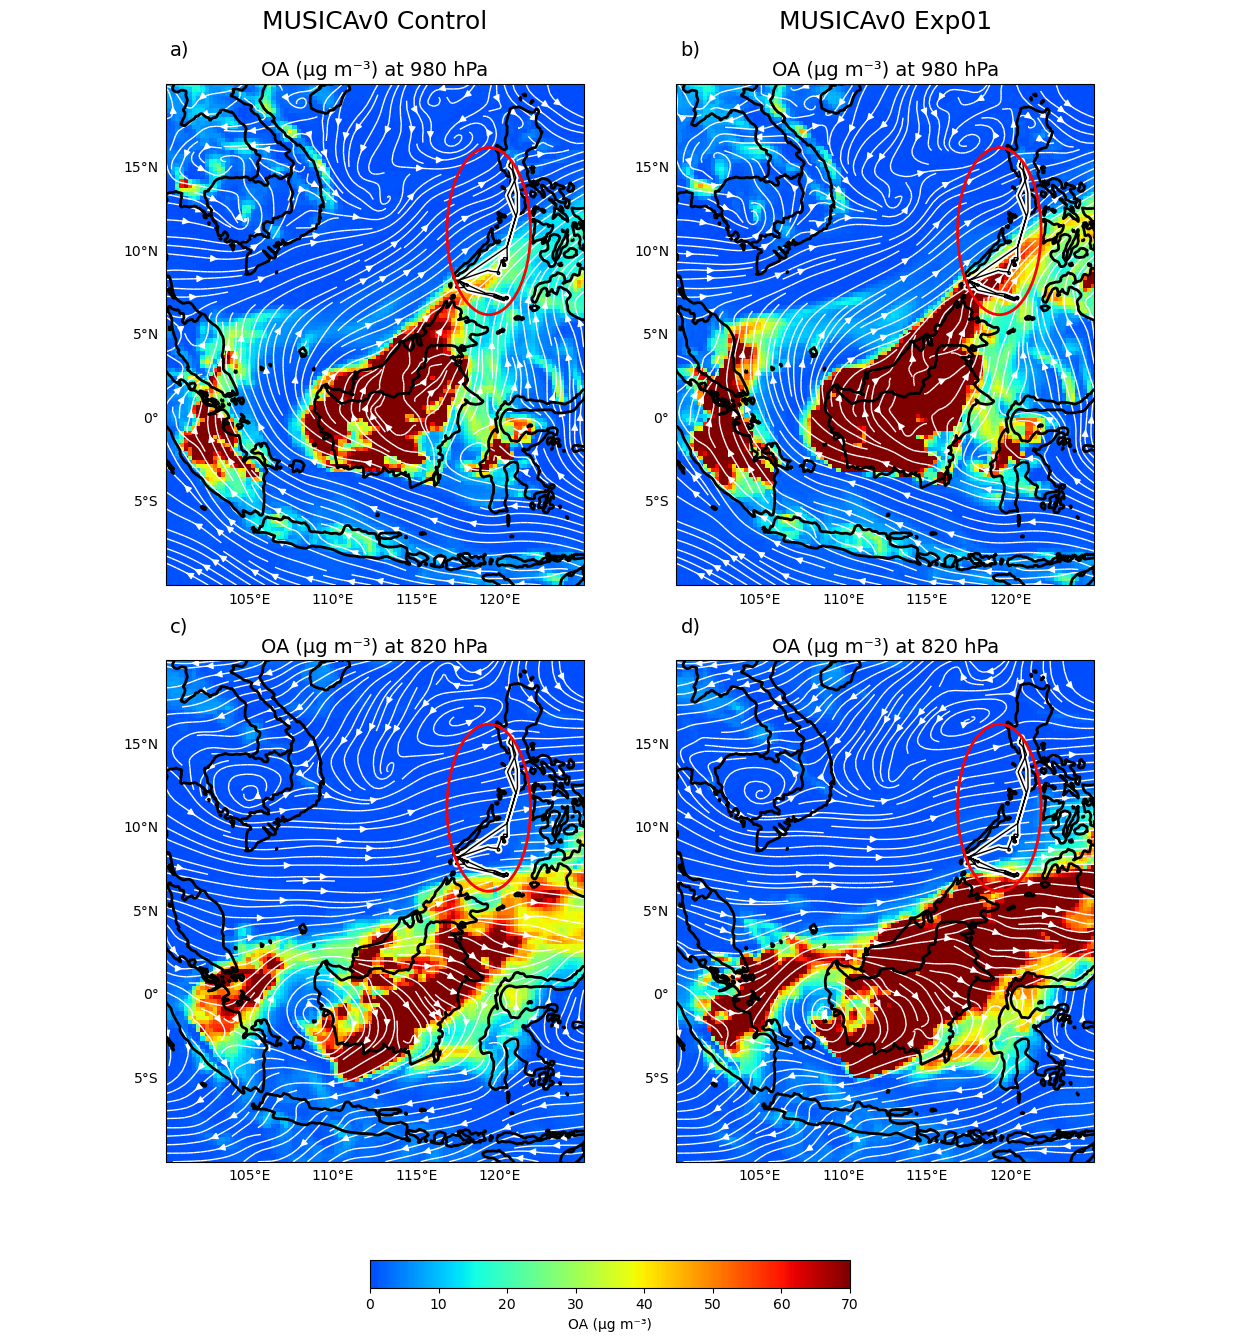

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cf
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
from matplotlib import cm

levels = [30, 24]          # lev indices
pressures = [980, 820]     # matching pressure labels

panel_labels = ['a)', 'b)', 'c)', 'd)']

col_titles = ["MUSICAv0 Control", "MUSICAv0 Exp01"]

datasets = [ds_wind_mean_Ctrl, ds_wind_mean_Exp01]

fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(2, 2, wspace=-0.3, hspace=0.15)

pla_proj = ccrs.PlateCarree()

p3_ug_m3 = 1.225 * 1000 * 1E6

panel = 0
for r, (lev, pres_) in enumerate(zip(levels, pressures)):
    for c, ds in enumerate(datasets):

        ds_lev = ds.isel(lev=lev)

        ax = fig.add_subplot(gs[r, c], projection=pla_proj)
        ax.set_extent([100, 125, -10, 20], crs=ccrs.PlateCarree())

        # OA field
        oa_model = p3_ug_m3 * (
            ds_lev['pom_a1'] + ds_lev['pom_a4'] +
            ds_lev['soa_a1'] + ds_lev['soa_a2']
        )

        cmap = cm.get_cmap(lighter_jet).copy()
        cmap.set_bad(color='k')

        # Panel label
        ax.text(0.01, 1.05, panel_labels[panel], transform=ax.transAxes,
                fontsize=14, va='bottom', ha='left')

        # Plot OA
        ref = oa_model.plot.pcolormesh(
            vmin=0, vmax=70, cmap=cmap,
            ax=ax, add_colorbar=False
        )

        # Winds
        ds_lev.plot.streamplot(
            'lon', 'lat', 'U', 'V',
            color='white', linewidth=1, density=2,
            ax=ax, zorder=1
        )
        ax.coastlines(resolution='50m', color='black', linewidth=2)
        ax.add_feature(cf.BORDERS, linewidth=2, edgecolor='black', zorder=2)
        ax.plot(p3data['lon'], p3data['lat'], color='white', lw=4,
                transform=ccrs.PlateCarree())
        ax.plot(p3data['lon'], p3data['lat'], color='k', lw=1,
                transform=ccrs.PlateCarree())
        center_lon = np.mean(p3data['lon'].values) - 0.25
        center_lat = np.mean(p3data['lat'].values) + 1.5
        big_ellipse = mpatches.Ellipse(
            (center_lon, center_lat),
            width=5, height=10,
            transform=ccrs.PlateCarree(),
            facecolor='none', edgecolor='red',
            linewidth=2, zorder=4
        )
        ax.add_patch(big_ellipse)
        gl = ax.gridlines(draw_labels=True, dms=True,
                          x_inline=False, y_inline=False)
        gl.xlines = False
        gl.ylines = False
        gl.right_labels = False
        gl.top_labels = False
        ax.set_title(f"OA (µg m⁻³) at {pres_} hPa", fontsize=14)

        panel += 1

for c, title in enumerate(col_titles):
    ax_title = fig.add_subplot(gs[0, c])
    ax_title.set_title(title, fontsize=18, pad=40)
    ax_title.set_axis_off()   # hide axes but KEEP the title

cbar_ax = fig.add_axes([0.35, 0.02, 0.3, 0.02])
plt.colorbar(ref, cax=cbar_ax, orientation='horizontal',
             label='OA (µg m⁻³)')

plt.show()